# Importer Le Fichier

In [1]:
import pandas as pd

pd.options.plotting.backend = "plotly"
df = pd.read_csv("dpt2022.csv", sep = ';')


In [2]:
df.columns.values

array(['sexe', 'preusuel', 'annais', 'dpt', 'nombre'], dtype=object)

In [3]:
df.shape

(3835767, 5)

In [4]:
sample = df.sample(n = 3000)

## la proportion totale Femmes / Hommes au cours du temps depuis 1900 

In [5]:
len(sample.query("sexe == 1"))

1394

In [6]:
len(sample.query("sexe == 2"))

1606

In [7]:
list(sample.groupby("sexe").size().items())

[(1, 1394), (2, 1606)]

In [8]:

total = sample.groupby("sexe")["nombre"].sum()
print(total)
print("pourcenatge")
print(total / total.sum() * 100)

sexe
1    30400
2    29524
Name: nombre, dtype: int64
pourcenatge
sexe
1    50.730926
2    49.269074
Name: nombre, dtype: float64


In [9]:
femmes = sample[sample["sexe"] == 2].groupby("annais")["nombre"].sum()
femmes


annais
1900     46
1901    170
1902    245
1903    219
1904    150
       ... 
2019    158
2020    113
2021    184
2022    190
XXXX    568
Name: nombre, Length: 124, dtype: int64

In [10]:
hommes = sample[sample["sexe"] == 1].groupby("annais")["nombre"].sum()
hommes

annais
1900      54
1901      12
1902     110
1903     111
1904      76
        ... 
2019     250
2020     114
2021     348
2022      80
XXXX    1883
Name: nombre, Length: 124, dtype: int64

## Evolution du prénom Marie dans le temps

In [11]:
marie = sample[sample["preusuel"] == "MARIE"].groupby("annais")["nombre"].sum()
marie

annais
1904       3
1972    2742
1974      20
1981      16
1991      36
2006      13
2016       9
Name: nombre, dtype: int64

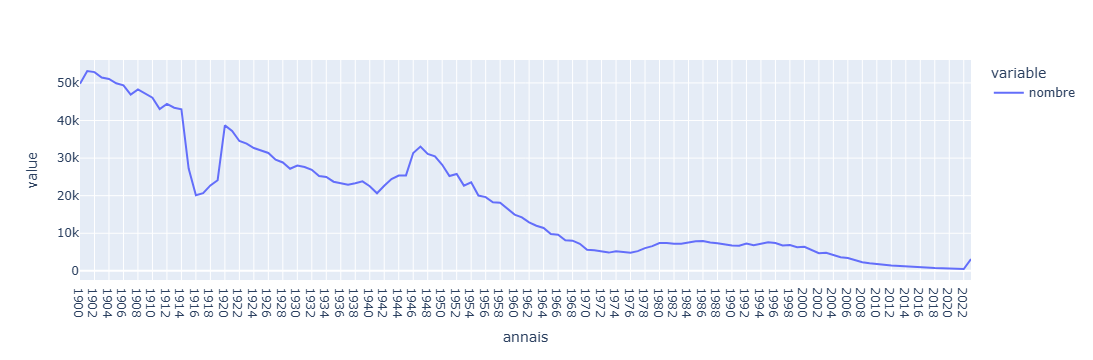

In [12]:
df[df["preusuel"] == "MARIE"].groupby("annais")["nombre"].sum().plot()

## En 2017, on recensait 13.000 prénoms différents, soit 7,6 fois plus qu'en 1900.

In [13]:
nom_2017 = df[df["annais"] == '2017']["preusuel"].nunique()
nom_2017

4719

In [14]:
nom_1900 = df[df["annais"] == '1900']["preusuel"].nunique()
nom_1900

998

In [15]:
nom_2017 / nom_1900

4.728456913827655

## " En 1900, parmi les prénoms recensés par l'Insee, le plus donné, Marie, représentait 11% des naissances."

In [16]:
 
marie_1900 = df.query("annais == '1900' and preusuel == 'MARIE'")["nombre"].sum()
total_1900 = df.query("annais == '1900'")["nombre"].sum()

print(round((marie_1900 / total_1900) * 100))

13


## " En 2017, des «prénoms rares» ont été donnés à près de 55 000 enfants, soit 10 fois plus que le prénom le plus donné (Gabriel). "

In [17]:
rares = df.query("annais == '2017' and preusuel == '_PRENOMS_RARES'")["nombre"].sum()
rares

np.int64(51898)

In [18]:
gabriel = df.query("annais == '2017' and preusuel == 'GABRIEL'")["nombre"].sum()
gabriel

np.int64(5442)

In [19]:
round(rares / gabriel)

10

## " Un pic a été atteint en 2012, avec plus de 13.643 prénoms recensés. "

In [20]:
# Prénoms normaux
normaux = df[(df["annais"] == "2012") & (df["preusuel"] != "_PRENOMS_RARES")]["preusuel"].nunique()
normaux

4621

In [21]:
# Prénoms rares
rare = df.query("annais == '2012' and preusuel == '_PRENOMS_RARES'")["nombre"].sum()
rare

np.int64(49927)

In [22]:
normaux + rare

np.int64(54548)

## Evolution des prénoms composés contenant Marie au cours du temps (Marie-Pierre, Marie-Paul, ….) ?
[ Aide : Aller voir comment traiter du texte en python → 'in' , regex, vectorized string functions de pandas, etc ]

In [23]:
marie_compose = df[df["preusuel"].str.upper().str.contains("MARIE", na=False)].groupby("annais")["nombre"].sum().plot()
marie_compose

## " 2015 : Les prénoms rares forment la première catégorie de prénoms "

In [24]:
# annee 2015 groupe by prenom somme des nombres
# nlargest retourne les premiers n resultats ordre desc
df[df["annais"] == "2015"].groupby("preusuel")["nombre"].sum().nlargest(5)

preusuel
_PRENOMS_RARES    50881
GABRIEL            5651
JULES              5153
LUCAS              5018
LOUIS              4748
Name: nombre, dtype: int64

## [Plus dur] Combien de prénoms faut-il pour nommer 50% des bébés par année (e.g. en 1900 27 prénoms suffisent) ?
[ Aide : Aller voir "groupby" de pandas. Passez un peu de temps à vous familiariser avec grâce aux ressources. Regardez également comment trier des données (ordre croissant/ décroissant) et la fonction cumsum de pandas. Confusion garantie au 1er abord ]

In [25]:
# somme des prenoms ples plus utilsés jusqu'a 50%
def prenoms_50(group):
    # 100%
    total = group["nombre"].sum()
    # trier les valeurs plus utilisés ==> moins
    trie = group.groupby("preusuel")["nombre"].sum().sort_values(ascending=False)
    # le cumul
    cumul = trie.cumsum()
    # true /false if cumul <50% true else false. +1 c'est pour compter le debord
    return (cumul <= total * 0.5).sum() +1


df_clean = df[df["preusuel"] != "_PRENOMS_RARES"]

resultat = df_clean.groupby("annais").apply(prenoms_50, include_groups=False)
print(resultat)


annais
1900      24
1901      24
1902      24
1903      24
1904      24
        ... 
2019     134
2020     137
2021     139
2022     139
XXXX    2123
Length: 124, dtype: int64


# La part des 10 prénoms les plus utilisés a-t-elle bien été divisée par 5 entre 1900 et aujourd'hui ?

In [26]:
df_clean = df[df["preusuel"] != "_PRENOMS_RARES"]
# on peux utiliser nlargest( nb, colonne) a  la place de sort puis head
les1900 = df_clean[df_clean["annais"] == "1900"].sort_values("nombre", ascending=False)["nombre"].head(10).sum()
les2017 = df_clean[df_clean["annais"] == "2017"].sort_values("nombre", ascending=False)["nombre"].head(10).sum()
print(les1900 // les2017)

5


## [Plus dur] Qu'en pensez vous ? Extrait du Figaro :
### À l'échelle régionale, le prénom Loïc, très populaire entre 1975 et 2000, constitue un bon exemple de cette circulation des prénoms. Cantonné à la Bretagne jusque dans les années 1980, il a essaimé en France jusqu'à être davantage donné dans d'autres régions, s'effaçant en Bretagne.

In [27]:
loic = df_clean[df_clean["preusuel"].str.lower() == "loïc"].copy()
loic = loic[loic["annais"] != "XXXX"].copy()
loic["annais"] = loic["annais"].astype(int)
loic["region"] = loic["dpt"].isin(["22", "29", "35", "56"])
# region true == bretagne / false == france
# comparter true /false pour les annees avant 1980 et apres
periode_1 = loic[(loic["annais"] >= 1975) & (loic["annais"] <= 1980)]
print("--- TOTAL DE 1975 A 1980 ---")
print(periode_1.groupby("region")["nombre"].sum())

periode_2 = loic[(loic["annais"] >= 1981) & (loic["annais"] <= 2000)]
print("\n--- TOTAL DE 1981 A 2000 ---")
print(periode_2.groupby("region")["nombre"].sum())


--- TOTAL DE 1975 A 1980 ---
region
False    11086
True       615
Name: nombre, dtype: int64

--- TOTAL DE 1981 A 2000 ---
region
False    54877
True       967
Name: nombre, dtype: int64


## [Plus dur] Qu'en pensez vous ? Extrait du Figaro :
### De même, les Erwan, Enora (bretons), Maelys (occitan) courent dans toute la France, tout comme les Wilfried (anglo-saxon), Enzo, Nino (italiens), Medhi, Inès (arabes) ou Lola (espagnol) ont fait leur trou. À l'inverse, les Armel (breton), Maite (basque), Giulia (italien) restent majoritairement limités à une région.

In [28]:
print("enzo")
enzo = df_clean[df_clean["preusuel"] == "ENZO"]
print(enzo.groupby("dpt")["nombre"].sum().sort_values(ascending=False).head(10))
print("armel")
armel = df_clean[df_clean["preusuel"] == "ARMEL"]
print(armel.groupby("dpt")["nombre"].sum().sort_values(ascending=False).head(10))

enzo
dpt
59    5317
13    4110
62    3221
69    3140
76    3089
75    3005
33    2934
93    2559
31    2543
44    2512
Name: nombre, dtype: int64
armel
dpt
XX     3380
56     1037
35      526
44      360
29      231
75      208
971     193
22      192
37       99
59       81
Name: nombre, dtype: int64


In [29]:
prenoms = ["ERWAN", "ENORA", "ENZO", "LOLA", "ARMEL", "MAITE", "GIULIA"]

for p in prenoms:
    total = df_clean[df_clean["preusuel"] == p]["nombre"].sum()
    top3_dpts = df_clean[df_clean["preusuel"] == p].groupby("dpt")["nombre"].sum().nlargest(3).sum()
    print(f"{p} : {round(top3_dpts/total*100, 1)}% dans ses 3 premiers départements")

ERWAN : 17.1% dans ses 3 premiers départements
ENORA : 27.6% dans ses 3 premiers départements
ENZO : 10.7% dans ses 3 premiers départements
LOLA : 10.7% dans ses 3 premiers départements
ARMEL : 70.7% dans ses 3 premiers départements
MAITE : 54.1% dans ses 3 premiers départements
GIULIA : 21.0% dans ses 3 premiers départements


# ATELIER 2

## Prediction de l'age apartir du nom

In [30]:
def age_par_nom(nom : str)-> int:
    # nettoyage
    # uniformiser tous / normaliser
    df_nom = df_clean[df_clean["preusuel"].str.lower() == nom.lower()].copy()
    # supprimer les XXXX des années
    df_nom = df_nom[df_nom["annais"] != "XXXX"].copy()
    # changer le type de l'annee de str en int
    df_nom["annais"] = df_nom["annais"].astype(int)
    # trancher 100 en arriere pour ne pas avoir des ages superieure a 100
    df_nom = df_nom[df_nom["annais"] >= 1926]
    # trouver l'année ou le nombre est max
    par_annee = df_nom.groupby("annais")["nombre"].sum()
    annee_peak = int(par_annee.idxmax())
 
    age = 2026 - annee_peak
    return age

print(age_par_nom("marie"))

79


## Premiere VS Derniere apparitions d'un nom données

In [31]:
def apparitions(nom: str) -> dict:
    df_nom = df_clean[df_clean["preusuel"].str.lower() == nom.lower()].copy()
    df_nom = df_nom[df_nom["annais"] != "XXXX"].copy()
    df_nom["annais"] = df_nom["annais"].astype(int)
    
    par_annee = df_nom.groupby("annais")["nombre"].sum()
    
    premiere = int(df_nom["annais"].min())
    derniere = int(df_nom["annais"].max())
    annee_peak = int(par_annee.idxmax())
    
    return {
        "prenom": nom.upper(),
        "premiere_apparition": premiere,
        "derniere_apparition": derniere,
        "duree": derniere - premiere,
        "annee_peak": annee_peak
    }

print(apparitions("marie"))
print(apparitions("lucas"))

{'prenom': 'MARIE', 'premiere_apparition': 1900, 'derniere_apparition': 2022, 'duree': 122, 'annee_peak': 1901}
{'prenom': 'LUCAS', 'premiere_apparition': 1920, 'derniere_apparition': 2022, 'duree': 102, 'annee_peak': 2002}


## TAUX DE CROISSANCE

## QUESTION 6 BEHIND THE NAME

In [32]:
df2 = pd.read_csv("dataset2.csv")
df2.shape

(20505, 5)

In [33]:
print(df2.columns.values)

['Unnamed: 0' 'gender' 'meaning' 'name' 'origin']


In [34]:
df2['origin']

0                   [Finnish (Rare)]
1                          [Finnish]
2                [Danish, Norwegian]
3                  [Medieval French]
4                           [Arabic]
                    ...             
20500                     [Georgian]
20501    [Croatian, Medieval Slavic]
20502                     [Croatian]
20503                   [Lithuanian]
20504                       [Polish]
Name: origin, Length: 20505, dtype: object

In [35]:
# les noms les plus multiculturels /origin == list / les 10 listes les plus longues
df2['origin_str'] = df2['origin'].str.strip('[]').str.split(', ')
top10 = df2.explode('origin_str').groupby('name')['origin_str'].nunique().nlargest(n=10)
top10


name
ANNA         28
MARIA        25
ADAM         23
SARA         22
DANIEL       21
ALEXANDRA    20
DAVID        20
EVA          20
MARINA       20
MARTA        19
Name: origin_str, dtype: int64

In [36]:
list(df2.query('name == "ANNA"')['origin'])

['[English, Italian, German, Dutch, Swedish, Norwegian, Danish, Finnish, Estonian, Latvian, Greek, Hungarian, Polish, Russian, Ukrainian, Belarusian, Czech, Slovak, Bulgarian, Icelandic, Faroese, Catalan, Occitan, Breton, Biblical, Old Church Slavic, Biblical Latin, Biblical Greek]']

In [37]:
df['preusuel'] = df['preusuel'].astype(str).str.upper().str.strip()
df2['name'] = df2['name'].astype(str).str.upper().str.strip("'\" ")

# avec map
dict_map = dict(zip(df2['name'], df2['origin']))

df['origine'] = df['preusuel'].map(dict_map)
df

,sexe,preusuel,annais,dpt,nombre,origine
0,1,_PRENOMS_RARES,1900,02,7,NaN
1,1,_PRENOMS_RARES,1900,04,9,NaN
2,1,_PRENOMS_RARES,1900,05,8,NaN
3,1,_PRENOMS_RARES,1900,06,23,NaN
4,1,_PRENOMS_RARES,1900,07,9,NaN
...,...,...,...,...,...,...
3835762,2,ZYA,2021,35,5,NaN
3835763,2,ZYA,XXXX,XX,290,NaN
3835764,2,ZYNA,2013,93,3,NaN
3835765,2,ZYNA,XXXX,XX,74,NaN


In [38]:
# avec merge 
df_fusionne = pd.merge(df, df2[['name', 'origin']], left_on='preusuel', right_on='name', how='left')
df_fusionne

,sexe,preusuel,annais,dpt,nombre,origine,name,origin
0,1,_PRENOMS_RARES,1900,02,7,NaN,NaN,NaN
1,1,_PRENOMS_RARES,1900,04,9,NaN,NaN,NaN
2,1,_PRENOMS_RARES,1900,05,8,NaN,NaN,NaN
3,1,_PRENOMS_RARES,1900,06,23,NaN,NaN,NaN
4,1,_PRENOMS_RARES,1900,07,9,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
3836986,2,ZYA,2021,35,5,NaN,NaN,NaN
3836987,2,ZYA,XXXX,XX,290,NaN,NaN,NaN
3836988,2,ZYNA,2013,93,3,NaN,NaN,NaN
3836989,2,ZYNA,XXXX,XX,74,NaN,NaN,NaN


In [39]:

print(df_fusionne['name'].dropna().nunique())

6893


In [40]:
print(df_fusionne['origin'].dropna())


11098                                               [Arabic]
11099                                               [Arabic]
11103      [English, Jewish, Biblical, Biblical Latin, Bi...
11104      [English, Jewish, Biblical, Biblical Latin, Bi...
11105      [English, Jewish, Biblical, Biblical Latin, Bi...
                                 ...                        
3836974                             [Polish, Latvian (Rare)]
3836975                             [Polish, Latvian (Rare)]
3836976                             [Polish, Latvian (Rare)]
3836977                             [Polish, Latvian (Rare)]
3836978                             [Polish, Latvian (Rare)]
Name: origin, Length: 2826382, dtype: object


In [41]:
print(df_fusionne.dtypes)

sexe         int64
preusuel    object
annais      object
dpt         object
nombre       int64
origine     object
name        object
origin      object
dtype: object


In [42]:
df_fusionne['origin_list'] = df_fusionne['origin'].dropna().astype(str).str.strip('[]').str.split(', ')
df_propres = df_fusionne.explode('origin_list')
df_propres = df_propres[df_propres["annais"] != "XXXX"].copy()
df_propres["annais"] = df_propres["annais"].astype(int)

df_propres[['annais', 'preusuel', 'origin_list', 'nombre','dpt']]

,annais,preusuel,origin_list,nombre,dpt
0,1900,_PRENOMS_RARES,NaN,7,02
1,1900,_PRENOMS_RARES,NaN,9,04
2,1900,_PRENOMS_RARES,NaN,8,05
3,1900,_PRENOMS_RARES,NaN,23,06
4,1900,_PRENOMS_RARES,NaN,9,07
...,...,...,...,...,...
3836983,2013,ZYA,NaN,3,59
3836984,2017,ZYA,NaN,3,974
3836985,2018,ZYA,NaN,3,59
3836986,2021,ZYA,NaN,5,35


In [43]:
diversite_par_an = df_propres.groupby('annais')['origin_list'].nunique().plot()

In [44]:
df_regions = df_propres[df_propres['origin_list'].isin(['Basque', 'Breton', 'Catalan'])]
evolution_regions = df_regions.groupby(['annais', 'origin_list'])['nombre'].sum().unstack().plot()

In [45]:
# Compter le nombre d'origines uniques dans tout le dataset
nb_origines_uniques = df_propres['origin_list'].nunique()

nb_origines_uniques

194

In [46]:
df_temporel = df_propres.pivot_table(
    index='annais', 
    columns='origin_list', 
    values='nombre', 
    aggfunc='sum'
).fillna(0)


fig = df_temporel.plot(
    title="Évolution temporelle des 194 origines",
    labels=dict(index="Année de naissance", value="Nombre de naissances", variable="Origines")
)

fig.update_layout(height=700,width = 1000, template="plotly_white")
fig.show()

In [47]:
df_temporel

origin_list,?),African American,African American (Modern),African American (Rare),Afrikaans,Akan,Albanian,American,American (Hispanic),Ancient Germanic,...,Uzbek,Various,Vietnamese,Welsh,Welsh (Anglicized),Welsh Mythology,Western African,Yiddish,Yoruba,Zapotec
annais,,,,,,,,,,,,,,,,,,,,,
1900,0.0,2066.0,0.0,0.0,0.0,0.0,40.0,0.0,0.0,8805.0,...,0.0,0.0,0.0,285.0,0.0,614.0,0.0,0.0,0.0,0.0
1901,0.0,2158.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,10455.0,...,0.0,0.0,0.0,325.0,0.0,574.0,0.0,0.0,0.0,0.0
1902,0.0,2127.0,0.0,0.0,0.0,0.0,43.0,0.0,0.0,10910.0,...,0.0,0.0,0.0,342.0,0.0,655.0,0.0,0.0,0.0,0.0
1903,0.0,2119.0,0.0,0.0,0.0,0.0,37.0,0.0,0.0,11311.0,...,0.0,0.0,0.0,311.0,0.0,596.0,0.0,0.0,0.0,0.0
1904,0.0,2157.0,0.0,0.0,0.0,0.0,45.0,0.0,0.0,11970.0,...,0.0,0.0,0.0,401.0,0.0,616.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018,0.0,1903.0,3.0,6.0,30.0,0.0,408.0,33.0,27.0,5799.0,...,24.0,3.0,7.0,2286.0,0.0,4111.0,376.0,116.0,0.0,0.0
2019,0.0,1794.0,3.0,3.0,60.0,0.0,373.0,29.0,46.0,5358.0,...,16.0,0.0,4.0,2050.0,3.0,4346.0,469.0,80.0,3.0,0.0
2020,0.0,1468.0,0.0,10.0,38.0,0.0,387.0,35.0,44.0,5358.0,...,25.0,0.0,3.0,1811.0,0.0,4056.0,480.0,65.0,0.0,0.0


In [48]:
df_dpt = df_propres.pivot_table(
    index='dpt', 
    columns='origin_list', 
    values='nombre', 
    aggfunc='sum'
).fillna(0)
#df_dpt = df_dpt.dropna(axis=1,how='all') drop all empty columns
df_dpt

origin_list,?),African American,African American (Modern),African American (Rare),Afrikaans,Akan,Albanian,American,American (Hispanic),Ancient Germanic,...,Uzbek,Various,Vietnamese,Welsh,Welsh (Anglicized),Welsh Mythology,Western African,Yiddish,Yoruba,Zapotec
dpt,,,,,,,,,,,,,,,,,,,,,
01,0.0,1455.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,13083.0,...,19.0,3.0,0.0,2118.0,0.0,1001.0,0.0,0.0,0.0,0.0
02,0.0,2259.0,0.0,0.0,0.0,0.0,131.0,0.0,0.0,24559.0,...,0.0,0.0,0.0,4968.0,0.0,2202.0,0.0,19.0,0.0,0.0
03,0.0,2408.0,0.0,0.0,0.0,0.0,156.0,0.0,0.0,15141.0,...,0.0,0.0,0.0,2320.0,0.0,1024.0,0.0,8.0,0.0,0.0
04,0.0,298.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,3331.0,...,0.0,0.0,0.0,506.0,0.0,231.0,0.0,0.0,0.0,0.0
05,0.0,424.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,3732.0,...,0.0,0.0,0.0,633.0,0.0,312.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971,0.0,1854.0,5.0,6.0,0.0,0.0,145.0,9.0,33.0,14585.0,...,0.0,40.0,0.0,3934.0,0.0,1452.0,3.0,177.0,0.0,3.0
972,0.0,2113.0,0.0,3.0,0.0,0.0,97.0,0.0,14.0,14439.0,...,0.0,0.0,0.0,4164.0,0.0,1295.0,3.0,135.0,0.0,0.0
973,0.0,574.0,12.0,49.0,0.0,0.0,3.0,4.0,17.0,2279.0,...,0.0,44.0,0.0,1157.0,0.0,779.0,3.0,108.0,0.0,4.0


In [49]:
nb_origines_par_dpt = (df_dpt > 0).sum(axis=1).sort_values(ascending=False).reset_index()
nb_origines_par_dpt.columns = ['Département', 'Nombre d\'origines uniques']
print(nb_origines_par_dpt)

   Département  Nombre d'origines uniques
0           75                        176
1           69                        159
2           59                        158
3           92                        157
4           93                        153
..         ...                        ...
95          05                         85
96          32                         84
97          15                         80
98          23                         79
99          48                         78

[100 rows x 2 columns]


In [50]:

fig = nb_origines_par_dpt.plot(
    kind='bar',
    x='Nombre d\'origines uniques',
    y='Département',
    orientation='h',
    title="La plus grande diversité d'origines de prénoms"
)

fig.update_layout(
    xaxis_title="Nombre d'origines uniques",
    yaxis_title="Département",
    yaxis={'categoryorder':'total ascending'}, 
    template="plotly_white")
fig.show()

In [51]:
import requests

API_KEY = "am068392744"
BASE_URL = "https://www.behindthename.com/api/lookup.json"

def get_name_info(name):
    params = {
        "name": name.lower(),
        "key": API_KEY
    }
    response = requests.get(BASE_URL, params=params)
    
    if response.status_code == 200:
        return response.json()
    else:
        return None

In [52]:
get_name_info("jean")

[{'name': 'Jean',
  'number': '1',
  'gender': 'm',
  'usages': [{'usage_code': 'fre',
    'usage_full': 'French',
    'usage_gender': 'm'}]},
 {'name': 'Jean',
  'number': '2',
  'gender': 'f',
  'usages': [{'usage_code': 'eng',
    'usage_full': 'English',
    'usage_gender': 'f'},
   {'usage_code': 'sco', 'usage_full': 'Scottish', 'usage_gender': 'f'}]}]

In [53]:
get_name_info("marie")

[{'name': 'Marie',
  'gender': 'fm',
  'usages': [{'usage_code': 'fre',
    'usage_full': 'French',
    'usage_gender': 'fm'},
   {'usage_code': 'cze', 'usage_full': 'Czech', 'usage_gender': 'f'},
   {'usage_code': 'ger', 'usage_full': 'German', 'usage_gender': 'f'},
   {'usage_code': 'eng', 'usage_full': 'English', 'usage_gender': 'f'},
   {'usage_code': 'swe', 'usage_full': 'Swedish', 'usage_gender': 'f'},
   {'usage_code': 'nor', 'usage_full': 'Norwegian', 'usage_gender': 'f'},
   {'usage_code': 'dan', 'usage_full': 'Danish', 'usage_gender': 'f'},
   {'usage_code': 'dut', 'usage_full': 'Dutch', 'usage_gender': 'f'},
   {'usage_code': 'alb', 'usage_full': 'Albanian', 'usage_gender': 'f'}]}]

In [54]:
get_name_info("mary")

[{'name': 'Mary',
  'gender': 'f',
  'usages': [{'usage_code': 'eng',
    'usage_full': 'English',
    'usage_gender': 'f'},
   {'usage_code': 'eng-bibl', 'usage_full': 'Biblical', 'usage_gender': 'f'}]}]

In [55]:
name = get_name_info("marie")[0]
name["usages"]

[{'usage_code': 'fre', 'usage_full': 'French', 'usage_gender': 'fm'},
 {'usage_code': 'cze', 'usage_full': 'Czech', 'usage_gender': 'f'},
 {'usage_code': 'ger', 'usage_full': 'German', 'usage_gender': 'f'},
 {'usage_code': 'eng', 'usage_full': 'English', 'usage_gender': 'f'},
 {'usage_code': 'swe', 'usage_full': 'Swedish', 'usage_gender': 'f'},
 {'usage_code': 'nor', 'usage_full': 'Norwegian', 'usage_gender': 'f'},
 {'usage_code': 'dan', 'usage_full': 'Danish', 'usage_gender': 'f'},
 {'usage_code': 'dut', 'usage_full': 'Dutch', 'usage_gender': 'f'},
 {'usage_code': 'alb', 'usage_full': 'Albanian', 'usage_gender': 'f'}]